In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Загрузка данных

In [2]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "uciml/red-wine-quality-cortez-et-al-2009"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/winequality-red.csv")

print(df.head())
print(df.info())
print(df.describe())

Dataset path: data/kagglehub_cache\datasets\uciml\red-wine-quality-cortez-et-al-2009\versions\2
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51      

# Анализ корреляции признаков

ТОП-10 корреляций с quality:
quality                 1.000000
alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
density                 0.174919
chlorides               0.128907
fixed acidity           0.124052
pH                      0.057731
Name: quality, dtype: float64


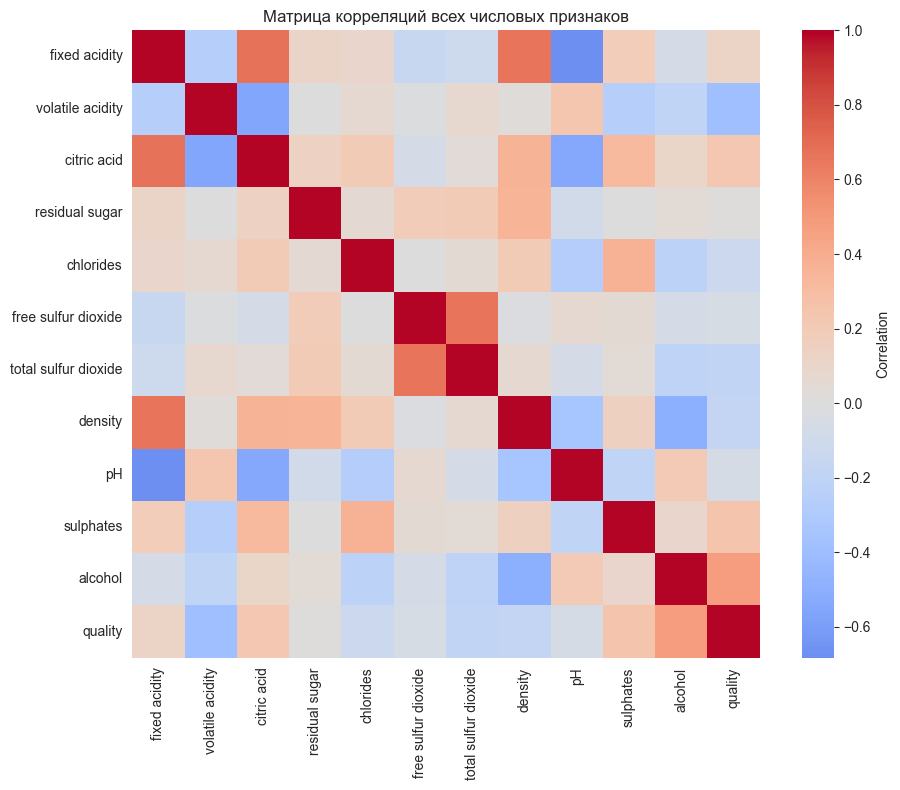

In [3]:
df.columns = df.columns.str.strip()

target = "quality"
numeric_df = df.select_dtypes(include=[np.number])

target_corr = numeric_df.corr()[target].abs().sort_values(ascending=False)
print("ТОП-10 корреляций с quality:")
print(target_corr.head(10))

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Матрица корреляций всех числовых признаков')
plt.tight_layout()
plt.show()

In [4]:
corr_matrix = numeric_df.corr()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

print("Пары с высокой корреляцией")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{feat1:25} - {feat2:25} = {corr:.4f}")

Пары с высокой корреляцией
pH                        - fixed acidity             = -0.6830
citric acid               - fixed acidity             = 0.6717
density                   - fixed acidity             = 0.6680
total sulfur dioxide      - free sulfur dioxide       = 0.6677
citric acid               - volatile acidity          = -0.5525
pH                        - citric acid               = -0.5419


# Группировка классов

In [5]:
def quality_group(q):

    if q <= 4:
        return "Low"

    elif q <= 6:
        return "Medium"

    else:
        return "High"


df["quality_group"] = df["quality"].apply(quality_group)

print("\nClass distribution")
print(df["quality_group"].value_counts())



Class distribution
quality_group
Medium    1319
High       217
Low         63
Name: count, dtype: int64


# Предобработка данных

In [6]:
le = LabelEncoder()

df["quality_encoded"] = le.fit_transform(df["quality_group"])

X = df.drop(["quality", "quality_group", "quality_encoded"], axis=1)
y = df["quality_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE:", X_train.shape)

Train size: (1279, 11)
Test size: (320, 11)
After SMOTE: (3165, 11)


# Логистическая регрессия

In [7]:
logreg = LogisticRegression(
    max_iter=200,
    random_state=42,
    class_weight='balanced'
)

logreg.fit(X_train, y_train)
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

Accuracy на train: 0.763
Accuracy на test:  0.622

Метрики по классам
              precision    recall  f1-score   support

        High       0.36      0.72      0.48        43
         Low       0.10      0.46      0.17        13
      Medium       0.93      0.61      0.74       264

    accuracy                           0.62       320
   macro avg       0.46      0.60      0.46       320
weighted avg       0.82      0.62      0.68       320



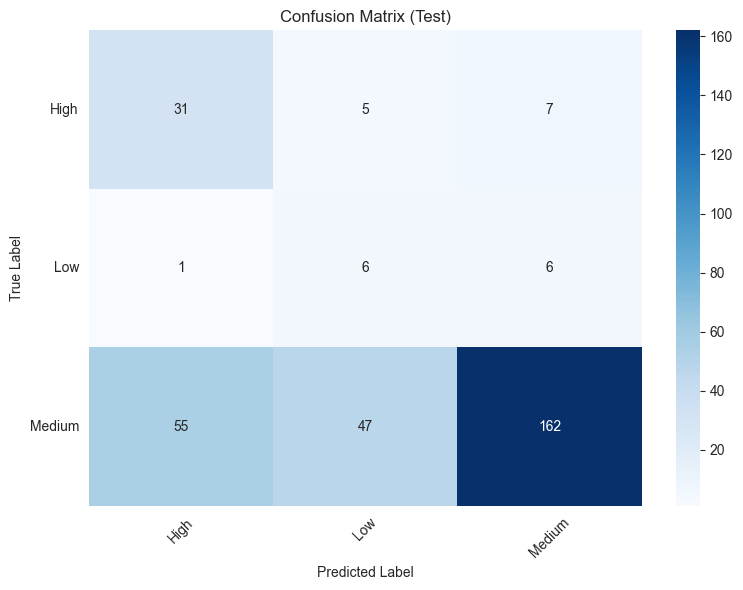

In [8]:
print(f"Accuracy на train: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_test_pred):.3f}")
print()

print("Метрики по классам")
target_names = le.classes_
print(classification_report(y_test, y_test_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()